In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

pd.set_option("display.max_colwidth", 120)


In [2]:
dataset_path = kagglehub.dataset_download("konradb/ethos-hate-speech-dataset")

print("Dataset downloaded to:")
print(dataset_path)

csv_files = glob.glob(
    os.path.join(dataset_path, "**", "*.csv"),
    recursive=True
)

print("\nCSV files found:")
for file in csv_files:
    print("-", file)


100%|██████████| 1.31M/1.31M [00:00<00:00, 23.3MB/s]

Extracting files...
Dataset downloaded to:
/root/.cache/kagglehub/datasets/konradb/ethos-hate-speech-dataset/versions/1

CSV files found:
- /root/.cache/kagglehub/datasets/konradb/ethos-hate-speech-dataset/versions/1/hate-speech-and-offensive-language.csv
- /root/.cache/kagglehub/datasets/konradb/ethos-hate-speech-dataset/versions/1/Ethos_Dataset_Multi_Label.csv
- /root/.cache/kagglehub/datasets/konradb/ethos-hate-speech-dataset/versions/1/en_dataset_with_stop_words.csv
- /root/.cache/kagglehub/datasets/konradb/ethos-hate-speech-dataset/versions/1/Ethos_Dataset_Binary.csv


## Load the binary hate-speech dataset

The loader searches for the binary ETHOS CSV and handles the semicolon-separated format used by the dataset.

In [3]:
binary_files = [
    f for f in csv_files
    if "binary" in os.path.basename(f).lower()
]

if not binary_files:
    raise FileNotFoundError(
        "Could not find the binary ETHOS CSV. Check the downloaded files above."
    )

file_path = binary_files[0]

# ETHOS binary CSV is semicolon-separated.
df = pd.read_csv(file_path, sep=";")

print("Loaded:", file_path)
print("\nShape:", df.shape)
print("\nColumns:", list(df.columns))
display(df.head())


Loaded: /root/.cache/kagglehub/datasets/konradb/ethos-hate-speech-dataset/versions/1/Ethos_Dataset_Binary.csv

Shape: (998, 2)

Columns: ['comment', 'isHate']


,comment,isHate
0,You should know women's sports are a joke,1.0
1,You look like Sloth with deeper Down’s syndrome,1.0
2,You look like Russian and speak like Indian. Both are disgusting go kill yourself,1.0
3,"Women deserve to be abused, I guess.",1.0
4,Women are made for making babies and cooking dinner and nothing else!!!,1.0


## Prepare the data

The original `isHate` field is a score. We convert it into a binary label using the ETHOS threshold of 0.5:
- `0` = Non-Hate
- `1` = Hate

In [4]:
data = df[["comment", "isHate"]].copy()

data = data.rename(columns={
    "comment": "text",
    "isHate": "label_score"
})

data["text"] = data["text"].astype(str).str.strip()

data = data.dropna(subset=["text"])
data = data[data["text"] != ""]
data = data.drop_duplicates(subset=["text"])

data["label"] = (data["label_score"] >= 0.5).astype(int)

print("Final dataset shape:", data.shape)

print("\nClass counts:")
print(data["label"].value_counts().sort_index())

print("\nClass percentages:")
print((data["label"].value_counts(normalize=True).sort_index() * 100).round(2))


Final dataset shape: (998, 3)

Class counts:
label
0    565
1    433
Name: count, dtype: int64

Class percentages:
label
0    56.61
1    43.39
Name: proportion, dtype: float64


##  Visualize class distribution

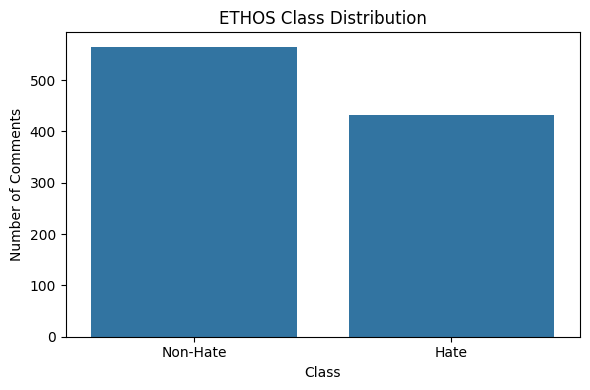

In [5]:
class_counts = data["label"].map({
    0: "Non-Hate",
    1: "Hate"
}).value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("ETHOS Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()


## Train/test split

We use an 80/20 stratified split so the hate/non-hate class proportions are preserved.

In [6]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 798
Testing samples: 200


## Build the NLP pipeline

**Text → TF-IDF → Logistic Regression**

We use unigrams and bigrams so the model can learn from both individual terms and short phrases.

In [7]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


## Evaluation

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

display(metrics_df.style.format({"Score": "{:.4f}"}))

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Hate", "Hate"],
        zero_division=0
    )
)


,Metric,Score
0,Accuracy,0.6950
1,Precision,0.6757
2,Recall,0.5747
3,F1-score,0.6211
4,ROC-AUC,0.7270



Classification Report:

              precision    recall  f1-score   support

    Non-Hate       0.71      0.79      0.74       113
        Hate       0.68      0.57      0.62        87

    accuracy                           0.69       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.69      0.69      0.69       200



## Confusion matrix

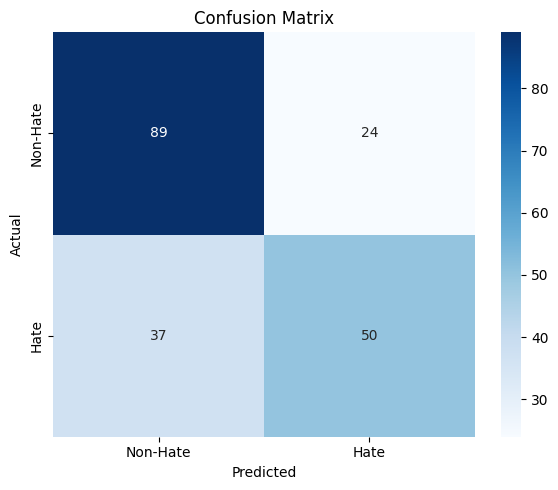

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Hate", "Hate"],
    yticklabels=["Non-Hate", "Hate"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## Bias / performance audit

We audit performance across two **text subgroups/styles**:

1. **Short vs. Long comments**
2. **Profanity vs. No Profanity**

These are text-style subgroups rather than demographic groups, which makes the audit directly reproducible from the binary ETHOS data.

In [10]:
audit_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual": y_test.reset_index(drop=True),
    "predicted": y_pred,
    "probability": y_prob
})

# Comment length
audit_df["word_count"] = audit_df["text"].apply(
    lambda x: len(str(x).split())
)

median_words = audit_df["word_count"].median()

audit_df["length_group"] = np.where(
    audit_df["word_count"] <= median_words,
    "Short",
    "Long"
)

# Simple profanity list for the audit
profanity_words = {
    "fuck", "fucking", "fucked", "shit", "bitch",
    "bastard", "asshole", "dick", "piss", "cunt",
    "motherfucker"
}

def contains_profanity(text):
    words = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    return any(word in profanity_words for word in words)

audit_df["profanity_group"] = audit_df["text"].apply(
    lambda x: "Profanity" if contains_profanity(x) else "No Profanity"
)

display(audit_df.head())
print("Median comment length:", median_words, "words")


,text,actual,predicted,probability,word_count,length_group,profanity_group
0,Equality should not apply on people of different religions except christianity.,1,0,0.369040,11,Short,No Profanity
1,That's a terrible photo to use.,0,0,0.444583,6,Short,No Profanity
2,If I had to meet one of the apostles I would fuck them for not killing him,1,1,0.501100,17,Long,Profanity
3,The best we thing we can do is Sterilize these women and try to save the children.,1,0,0.312048,17,Long,No Profanity
4,"If I was your dad, I would have cut your penis and make you it, because it’s useless for you",1,0,0.441801,20,Long,No Profanity


Median comment length: 14.0 words


In [11]:
def subgroup_metrics(df_subset):
    return {
        "Samples": len(df_subset),
        "Accuracy": accuracy_score(
            df_subset["actual"],
            df_subset["predicted"]
        ),
        "Precision": precision_score(
            df_subset["actual"],
            df_subset["predicted"],
            zero_division=0
        ),
        "Recall": recall_score(
            df_subset["actual"],
            df_subset["predicted"],
            zero_division=0
        ),
        "F1": f1_score(
            df_subset["actual"],
            df_subset["predicted"],
            zero_division=0
        )
    }

audit_results = []

for group in ["Short", "Long"]:
    subset = audit_df[audit_df["length_group"] == group]
    audit_results.append({
        "Audit": "Comment Length",
        "Group": group,
        **subgroup_metrics(subset)
    })

for group in ["Profanity", "No Profanity"]:
    subset = audit_df[audit_df["profanity_group"] == group]
    audit_results.append({
        "Audit": "Profanity",
        "Group": group,
        **subgroup_metrics(subset)
    })

audit_results_df = pd.DataFrame(audit_results)

display(
    audit_results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}"
    })
)


,Audit,Group,Samples,Accuracy,Precision,Recall,F1
0,Comment Length,Short,104,0.683,0.610,0.595,0.602
1,Comment Length,Long,96,0.708,0.758,0.556,0.641
2,Profanity,Profanity,31,0.677,0.680,0.895,0.773
3,Profanity,No Profanity,169,0.698,0.673,0.485,0.564


### Audit visualization

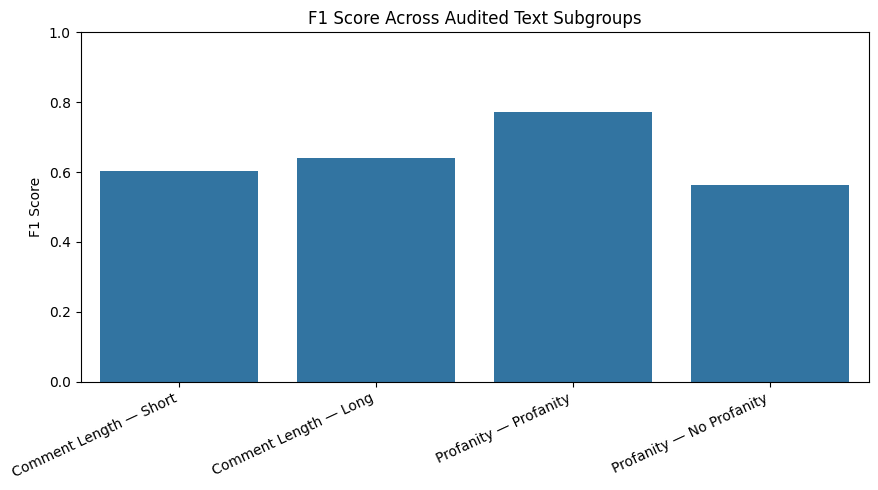

In [12]:
plot_df = audit_results_df.copy()
plot_df["Label"] = plot_df["Audit"] + " — " + plot_df["Group"]

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="Label", y="F1")
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.xlabel("")
plt.title("F1 Score Across Audited Text Subgroups")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Inspect possible shortcut behavior

This checks false positives in profanity-containing comments. A useful audit question is whether the model treats profanity as a shortcut for hate speech even when the text is labeled non-hate.

In [13]:
profanity_false_positives = audit_df[
    (audit_df["profanity_group"] == "Profanity") &
    (audit_df["actual"] == 0) &
    (audit_df["predicted"] == 1)
].sort_values("probability", ascending=False)

print("Profanity false positives:", len(profanity_false_positives))

display(
    profanity_false_positives[
        ["text", "probability", "actual", "predicted"]
    ].head(15)
)


Profanity false positives: 8


,text,probability,actual,predicted
183,Holy shit! Kill them all !,0.735661,0,1
94,Bro just delete yo shit off YouTube rn. Fuck outta here with yo clout chasing ass.,0.676579,0,1
146,they are all fucking assholes,0.664359,0,1
53,Id beat the fuck out of his ass if he wasnt an actor,0.628626,0,1
101,Fuck him and his prophet,0.533626,0,1
42,What the fuck stupid people !!!,0.527395,0,1
29,I’m very sad about this fucking situation with all this muslims,0.523191,0,1
142,I'm very sad about this fucking situation with all this muslims,0.523191,0,1


## Explainability — top learned features

Logistic Regression assigns a coefficient to each TF-IDF feature:
- Positive coefficient → pushes the prediction toward **Hate**
- Negative coefficient → pushes the prediction toward **Non-Hate**

In [14]:
vectorizer = model.named_steps["tfidf"]
classifier = model.named_steps["classifier"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = classifier.coef_[0]

top_n = 20

hate_idx = np.argsort(coefficients)[-top_n:][::-1]
nonhate_idx = np.argsort(coefficients)[:top_n]

hate_features = pd.DataFrame({
    "Feature": feature_names[hate_idx],
    "Coefficient": coefficients[hate_idx]
})

nonhate_features = pd.DataFrame({
    "Feature": feature_names[nonhate_idx],
    "Coefficient": coefficients[nonhate_idx]
})

print("Top features associated with HATE:")
display(hate_features.style.format({"Coefficient": "{:.4f}"}))

print("Top features associated with NON-HATE:")
display(nonhate_features.style.format({"Coefficient": "{:.4f}"}))


Top features associated with HATE:


,Feature,Coefficient
0,ass,1.4239
1,kill,1.1557
2,gays,1.1343
3,fuck,1.1036
4,stupid,1.0709
5,fat,0.9837
6,niggers,0.9569
7,bitch,0.9294
8,islam,0.9102
9,don,0.9037


Top features associated with NON-HATE:


,Feature,Coefficient
0,love,-1.1532
1,can,-1.0982
2,me,-1.0592
3,the,-1.0219
4,am,-0.9393
5,but,-0.8862
6,not,-0.7381
7,so,-0.7302
8,children,-0.7180
9,it,-0.6562


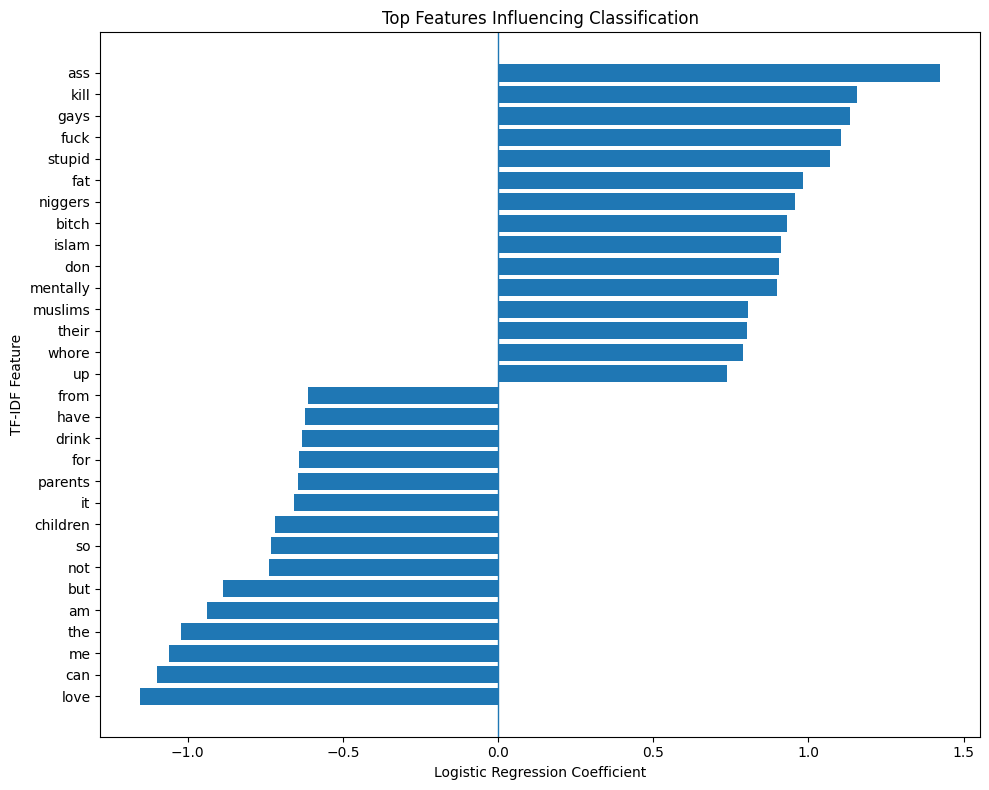

In [15]:
# Visualize the strongest positive and negative features
top_n_plot = 15

hate_plot_idx = np.argsort(coefficients)[-top_n_plot:]
nonhate_plot_idx = np.argsort(coefficients)[:top_n_plot]

plot_features = np.concatenate([
    feature_names[nonhate_plot_idx],
    feature_names[hate_plot_idx]
])

plot_values = np.concatenate([
    coefficients[nonhate_plot_idx],
    coefficients[hate_plot_idx]
])

plt.figure(figsize=(10, 8))
plt.barh(plot_features, plot_values)
plt.axvline(0, linewidth=1)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("TF-IDF Feature")
plt.title("Top Features Influencing Classification")
plt.tight_layout()
plt.show()


## Example predictions

These examples are only for demonstration and are **not** part of the evaluation set.

In [16]:
examples = [
    "I really enjoyed this video",
    "You are such an idiot",
    "People from that group should leave",
    "This movie was absolutely terrible",
    "I disagree with your opinion"
]

example_predictions = model.predict(examples)
example_probabilities = model.predict_proba(examples)[:, 1]

for text, pred, prob in zip(
    examples,
    example_predictions,
    example_probabilities
):
    label = "Hate Speech" if pred == 1 else "Non-Hate Speech"
    print(f"Text: {text}")
    print(f"Prediction: {label}")
    print(f"Hate probability: {prob:.3f}")
    print("-" * 70)


Text: I really enjoyed this video
Prediction: Non-Hate Speech
Hate probability: 0.359
----------------------------------------------------------------------
Text: You are such an idiot
Prediction: Non-Hate Speech
Hate probability: 0.429
----------------------------------------------------------------------
Text: People from that group should leave
Prediction: Non-Hate Speech
Hate probability: 0.358
----------------------------------------------------------------------
Text: This movie was absolutely terrible
Prediction: Non-Hate Speech
Hate probability: 0.411
----------------------------------------------------------------------
Text: I disagree with your opinion
Prediction: Hate Speech
Hate probability: 0.570
----------------------------------------------------------------------
